In [1]:
%load_ext autoreload
%autoreload 2

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm
import pickle
from datetime import datetime
from pathlib import Path

import sys
sys.path.append('../../')
from codebase.pairwise_copy_spatial_simulations import Simulate_Fish_School_Excluded_Volume
from codebase.subgroup_analysis import convert_to_focal_distance
from matplotlib.ticker import MaxNLocator

In [3]:
fish_ages = [2,4,6,8] # weeks
bodylengths = [4,7,10,12] # mm, from Zada et. al. 2024
arena_radius = [75, 150, 150, 150] # mm, radius of experimental arena for each age group

with open('../../Results/experiments_subgroup_analysis_results.pkl', 'rb') as f:
    data_focal_distances_agewise = pickle.load(f)["focal_distances"]

microscopic_params = pd.read_csv('../../Results/microscopic_params_full_dataset.csv').to_numpy()

# Quantify angular density of neighbors in data
We will calculate angular density using neighbors radial distance $R\leq 2$ bodylengths away, to capture the short-range angular anisotropy observed in spatial density plots. Optimal turn magnitude $\omega$ for simulations is the one that results in the best match to the angular density curves seen in data.

In [4]:
nbins_theta = 60
bins_theta_edges = np.linspace(-np.pi, np.pi, nbins_theta+1)
angular_density_curves_data = []

for j in range(len(fish_ages)):
    dLR = data_focal_distances_agewise[j][:,0]
    dFB = data_focal_distances_agewise[j][:,1]

    r = np.sqrt(dLR**2 + dFB**2)
    head_angles = np.arctan2(dFB, dLR)  # angle measured from x axis. heading angle of focal fish = pi/2 in these coordinates
    # bin data by angle (only considering r < 2 * BL)
    theta_red = head_angles[r < 2 * bodylengths[j]]
    angular_hist, _ = np.histogram(theta_red, bins=bins_theta_edges, density=True)
    bins_t = (bins_theta_edges[:-1] + bins_theta_edges[1:]) / 2
    angular_density_curves_data.append(np.column_stack((bins_t,angular_hist)))


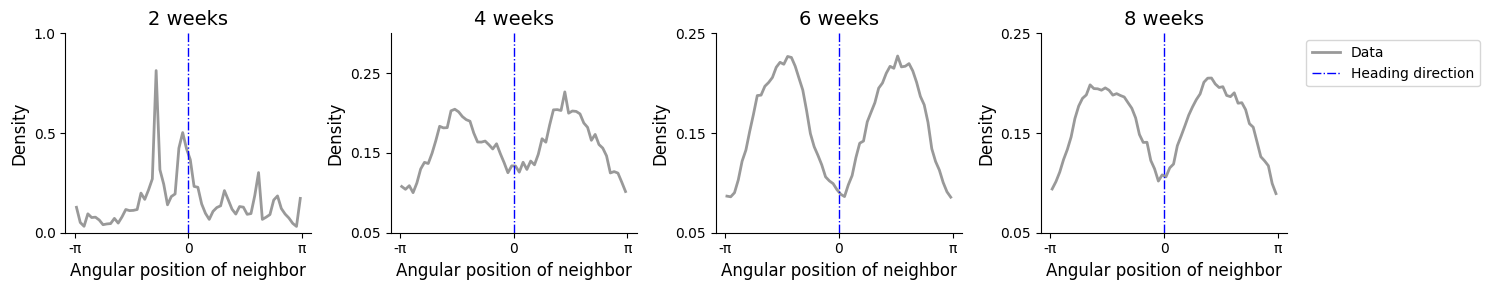

In [11]:
# angular density data 
fig, ax = plt.subplots(1, 4, figsize=(15, 3))
lims = [[0,1], [0.05,0.3], [0.05,0.25], [0.05,0.25]]
ticks = [[0,0.5,1], [0.05,0.15,0.25], [0.05,0.15,0.25], [0.05,0.15,0.25]]
for j in range(len(fish_ages)):
    angles = np.copy(angular_density_curves_data[j][:,0])
    angles[angles<-np.pi/2] += 2*np.pi
    angles = angles - np.pi/2 # shift so that 0 is heading direction

    # sort angles and corresponding densities
    sorted_indices = np.argsort(angles)
    angles = angles[sorted_indices]
    ax[j].plot(angles, angular_density_curves_data[j][sorted_indices,1], color='grey', label='Data', linewidth=2, alpha=0.8)
    ax[j].set_title(f"{fish_ages[j]} weeks", fontsize=14)
    ax[j].set_xlabel('Angular position of neighbor', fontsize=12)
    ax[j].set_ylabel('Density', fontsize=12)
    ax[j].set_xticks([-np.pi, 0, np.pi],['-π', '0',  'π'])
    ax[j].tick_params(axis='both', which='major', labelsize=10)
    ax[j].set_ylim(lims[j])
    ax[j].set_yticks(ticks[j])
    #ax[j].yaxis.set_major_locator(MaxNLocator(nbins=4))
    # turn off top and right spines
    ax[j].spines['top'].set_visible(False)
    ax[j].spines['right'].set_visible(False)
    ax[j].axvline(0, color='b', linestyle='-.', linewidth=1, label='Heading direction')
ax[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
fig.tight_layout()

# Perform a grid search over $\omega$ to find optimal turn magnitude
Save raw dFB and dLR values for each $\omega$

In [5]:
n_sims = 100
dt = 0.01 #s
Tmax = 600 #s
L = 50 #mm
omega_list = 10**np.linspace(-2.5,0,21)
N = 4

results_path = Path('../../Results/excluded_volume_param_scan_results.pkl')
if results_path.is_file():
    # load results 
    with open(results_path, 'rb') as f:
        results = pickle.load(f)
        MSE_angular_density = results['MSE_angular_density']
        angular_histograms = results['angular_histograms']
else:
    MSE_angular_density = np.zeros((len(omega_list), len(fish_ages)))
    angular_histograms = np.zeros((len(omega_list), len(fish_ages), nbins_theta,2))

    for i,omega in enumerate(omega_list):  

        for j in range(len(fish_ages)):
            R = arena_radius[j] #mm, radius of arena
            s = microscopic_params[j,0] * np.ones(N) # s^-1, rate of diffusion
            eps = microscopic_params[j,1]* np.ones(N) # std of diffusion noise
            c = microscopic_params[j,2]* np.ones(N) # s^-1, rate of copying 
            v = np.ones(N)*microscopic_params[j,3] #mm/s, velocity of each fish

            R_ex = bodylengths[j] # excluded volume radius
            
            dFB_all_sims = []
            dLR_all_sims = []

            for kk in range(n_sims):
                sim = Simulate_Fish_School_Excluded_Volume(N=N,v=v,R=R,s=s,eps=eps,c=c,Tmax=Tmax,dt=dt, L=L,R_ex=R_ex,omega=omega,seed=kk)
                x, y, head_angles = sim.run_simulation()
                for f in range(N):
                    dFB, dLR = convert_to_focal_distance(f,x,y,head_angles)
                    nan_mask = np.isfinite(dLR+dFB)
                    dFB_all_sims.append(dFB[nan_mask])
                    dLR_all_sims.append(dLR[nan_mask])

            dFB_all_sims = np.concatenate(dFB_all_sims)
            dLR_all_sims = np.concatenate(dLR_all_sims)

            r = np.sqrt(dLR_all_sims**2 + dFB_all_sims**2)
            theta = np.arctan2(dFB_all_sims, dLR_all_sims)  # angle measured from x axis. heading angl of focal fish = pi/2 in these coordinates

            # bin data by angle (only considering r < 2 * BL)
            theta_red = theta[r < 2 * bodylengths[j]]
            angular_hist, _ = np.histogram(theta_red, bins=bins_theta_edges, density=True)
            # compute error between simulation and data
            angular_error = np.mean((angular_hist - angular_density_curves_data[j][:,1])**2)
            MSE_angular_density[i,j] = angular_error
            angular_histograms[i,j,:,0] = (bins_theta_edges[:-1] + bins_theta_edges[1:]) / 2
            angular_histograms[i,j,:,1] = angular_hist

        print(f"Finished omega={omega:.3f} at {datetime.now()}")

    # save results 
    with open('../../Results/excluded_volume_param_scan_results.pkl', 'wb') as f:
        pickle.dump({
            'omega_list': omega_list,
            'MSE_angular_density': MSE_angular_density,
            'angular_histograms': angular_histograms
        }, f)

Finished omega=0.003 at 2026-07-25 20:17:05.318426
Finished omega=0.004 at 2026-07-25 20:30:18.820218
Finished omega=0.006 at 2026-07-25 20:42:22.675871
Finished omega=0.007 at 2026-07-25 20:53:46.868213
Finished omega=0.010 at 2026-07-25 21:05:12.898158
Finished omega=0.013 at 2026-07-25 21:16:43.295969
Finished omega=0.018 at 2026-07-25 21:28:48.737473
Finished omega=0.024 at 2026-07-25 21:41:30.863806
Finished omega=0.032 at 2026-07-25 21:53:47.777570
Finished omega=0.042 at 2026-07-25 22:06:37.710637
Finished omega=0.056 at 2026-07-25 22:20:19.696320
Finished omega=0.075 at 2026-07-25 22:33:07.005931
Finished omega=0.100 at 2026-07-25 22:46:30.686342
Finished omega=0.133 at 2026-07-25 22:59:28.314045
Finished omega=0.178 at 2026-07-25 23:12:14.734713
Finished omega=0.237 at 2026-07-25 23:24:00.606306
Finished omega=0.316 at 2026-07-25 23:35:27.144760
Finished omega=0.422 at 2026-07-25 23:46:53.230362
Finished omega=0.562 at 2026-07-25 23:58:18.083214
Finished omega=0.750 at 2026-07

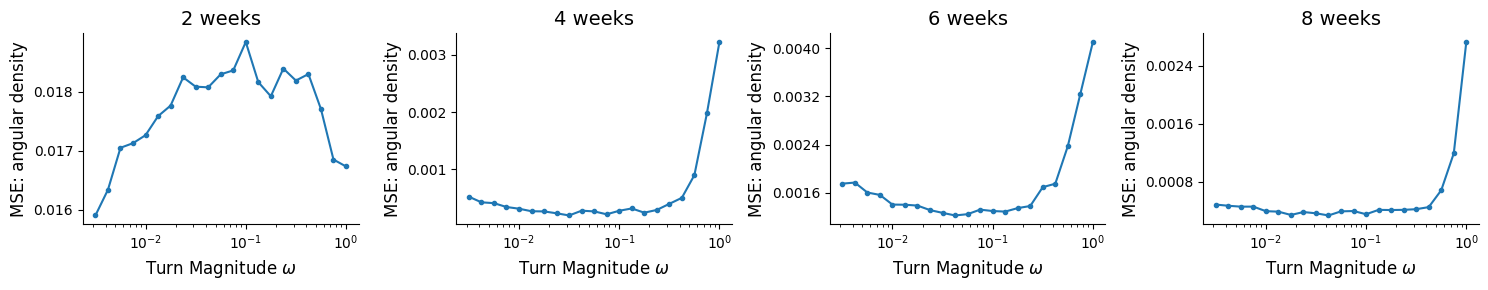

In [8]:
# plot MSE vs turn magnitude omega for each age
fig, ax = plt.subplots(1,4,figsize=(15, 3))
for j in range(len(fish_ages)):
    ax[j].plot(omega_list, MSE_angular_density[:,j], label=f"{fish_ages[j]} weeks", marker='.')
    ax[j].set_xlabel(r'Turn Magnitude $\omega$', fontsize=12)
    ax[j].set_ylabel('MSE: angular density', fontsize=12)
    ax[j].set_xscale('log')
    ax[j].set_title(f"{fish_ages[j]} weeks", fontsize=14)
    # turn off top and right spines
    ax[j].spines['top'].set_visible(False)
    ax[j].spines['right'].set_visible(False)
    ax[j].tick_params(axis='both', which='major', labelsize=10)
    ax[j].set_xticks([0.01,0.1,1])
    ax[j].yaxis.set_major_locator(MaxNLocator(nbins=4))
fig.tight_layout()

### Find optimal $\omega$ by averaging MSE for 4-8 weeks
2wpf fish do not show marked angular anisotropy, so we will only use data from 4-8 wpf fish 

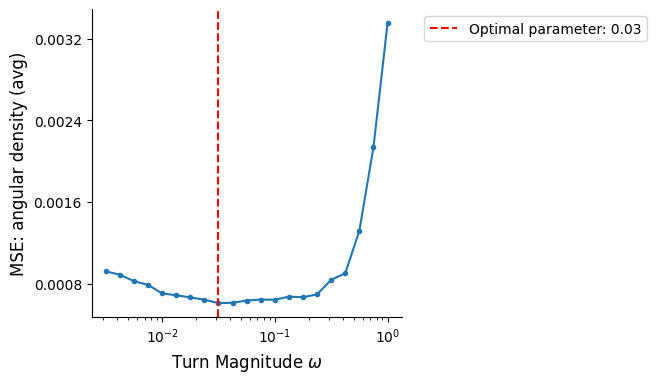

In [10]:
# avg 4-8 weeks and find optimal
MSE_angular_avg = np.mean(MSE_angular_density[:,1:], axis=1)
omega_optimal = omega_list[np.argmin(MSE_angular_avg)]

fig, ax = plt.subplots(1,1,figsize=(4, 4))
ax.plot(omega_list, MSE_angular_avg, marker='.')
ax.axvline(omega_optimal, color='r', linestyle='--', label=f'Optimal parameter: {omega_optimal:.2f}')
ax.set_xlabel(r'Turn Magnitude $\omega$', fontsize=12)
ax.set_ylabel('MSE: angular density (avg)', fontsize = 12)
ax.set_xscale('log')
# turn off top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.set_xticks([0.01,0.1,1])
ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')



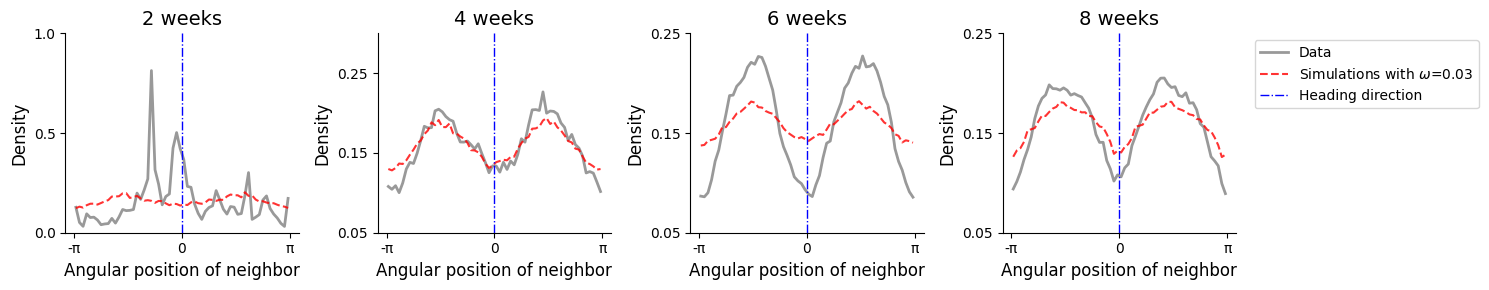

In [15]:
# angular density simulation results for optimal turn magnitude
fig, ax = plt.subplots(1, 4, figsize=(15, 3))
lims = [[0,1], [0.05,0.3], [0.05,0.25], [0.05,0.25]]
ticks = [[0,0.5,1], [0.05,0.15,0.25], [0.05,0.15,0.25], [0.05,0.15,0.25]]
for j in range(len(fish_ages)):
    angles = np.copy(angular_density_curves_data[j][:,0])
    angles[angles<-np.pi/2] += 2*np.pi
    angles = angles - np.pi/2 # shift so that 0 is heading direction

    # sort angles and corresponding densities
    sorted_indices = np.argsort(angles)
    angles = angles[sorted_indices]
    ax[j].plot(angles, angular_density_curves_data[j][sorted_indices,1], color='grey', label='Data', linewidth=2, alpha=0.8)
    ax[j].plot(angles, angular_histograms[np.argmin(MSE_angular_avg),j,sorted_indices,1], color='r', linestyle='--', label=fr'Simulations with $\omega$={omega_optimal:.2f}', linewidth=1.5, alpha=0.8)
    ax[j].set_title(f"{fish_ages[j]} weeks", fontsize=14)
    ax[j].set_xlabel('Angular position of neighbor', fontsize=12)
    ax[j].set_ylabel('Density', fontsize=12)
    ax[j].set_xticks([-np.pi, 0, np.pi],['-π', '0',  'π'])
    ax[j].tick_params(axis='both', which='major', labelsize=10)
    ax[j].set_ylim(lims[j])
    ax[j].set_yticks(ticks[j])
    #ax[j].yaxis.set_major_locator(MaxNLocator(nbins=4))
    # turn off top and right spines
    ax[j].spines['top'].set_visible(False)
    ax[j].spines['right'].set_visible(False)
    ax[j].axvline(0, color='b', linestyle='-.', linewidth=1, label='Heading direction')
ax[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
fig.tight_layout()

In [16]:
omega_optimal

np.float64(0.03162277660168379)